# AI MiniLab - Logistic Regression and SVM
**Course:** DS 7331 – Artificial Intelligence I 
**Team Members:** Johnny Vogt, Drew Nunnally, Devin Streeter, Mike Flores  
**Date:** 1/25/2026

---

## Business Understanding

Phishing attacks are a significant cybersecurity threat in which malicious websites attempt to deceive users into revealing sensitive information such as login credentials, financial data, or personal information. These attacks have proven effective at bypassing human intuition, even among vigilant users, and often result in financial loss or reputational damage. As phishing techniques continue to evolve, automated detection methods are increasingly necessary to protect users and organizations.

The dataset used in this project consists of URLs accompanied by a variety of attributes describing both the structure of the URL and characteristics of the associated website. Each URL is assigned a binary label indicating whether it is classified as a **phishing** or **legitimate** website (1 = legitimate, 0 = phishing). The dataset was collected to support the study and detection of phishing websites and to enable the development of predictive models that can identify malicious links before users interact with them.

The primary objective of this analysis is to understand how individual features relate to the phishing classification and to determine which attributes are most informative for distinguishing between legitimate and phishing websites. If meaningful differences exist between the patterns of phishing and legitimate URLs, then the dataset provides useful information for building effective prediction models. Preliminary feature correlations, such as indicators related to copyright information, social network presence, and special character usage in URLs, suggest that certain attributes may be associated with specific classifications.

A successful prediction model in this context prioritizes the accurate detection of phishing websites while minimizing misclassification of legitimate sites. From a practical standpoint, false negatives—failing to identify phishing links—pose a greater risk than false positives, as undetected phishing attacks can lead to significant security breaches and financial harm. Therefore, this exploratory analysis focuses on understanding the structure, distributions, and relationships within the data to support effective phishing detection in subsequent modeling efforts.

**Source:**  
Prasad, A., & Chandra, S. (2023). *PhiUSIIL: A diverse security profile empowered phishing URL detection framework based on similarity index and incremental learning*. Computers & Security, 103545. https://doi.org/10.1016/j.cose.2023.103545


## Load Libraries

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Display utilities
from IPython.display import display

from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
# Import dataset
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

## Display dataset dimensions (rows, columns)

In [3]:
rows, cols = df.shape
print(f"The dataset contains {rows:,} rows and {cols} columns.")

The dataset contains 235,795 rows and 56 columns.


## Check for missing data
EDA showed that there was no missing data

## Check for duplicate data

In [22]:
# Check for duplicate rows
print("Duplicate Rows")
# Counts ONLY exact row level duplicates
display(df.duplicated().sum())

print("Duplicate URLs (only)")
# Many URLs appear more than once, but with small differences in feature values
# (e.g., URLLength differs by 1 due to data collection timing or parsing)
# These are NOT full row duplicates, only URL-level duplicates
# Count duplicate values based only on the URL column
# It is safe to just drop all duplicates
display(df.duplicated(subset=["URL"]).sum())

Duplicate Rows


np.int64(0)

Duplicate URLs (only)


np.int64(425)

Duplicates Summary

A total of **425 duplicate URLs** were identified in the dataset. These duplicates correspond to repeated occurrences of the same URL while exhibiting minor variations in certain feature values. As a result, these records are not exact row-level duplicates but represent multiple observations associated with the same URL.

To avoid potential bias and redundancy in downstream analysis, duplicate URLs were removed by retaining only the first occurrence of each URL. The number of removed records represents approximately **0.18%** of the dataset, and therefore this preprocessing step is not expected to materially affect the overall analysis or modeling results.


Deal with the duplicate URLs by dropping the duplicate and keeping the first occurence.

In [23]:
# Drop the duplicate URLs code
# Identify duplicate URLs
dup_url_mask = df.duplicated(subset=["URL"], keep=False)

# Remove duplicate URLs (keep the first occurrence)
df_dedup = df.drop_duplicates(subset=["URL"], keep="first")

rows, cols = df_dedup.shape
print(f"After dropping the duplicate URLs, the dataset contains {rows:,} rows and {cols} columns.")

After dropping the duplicate URLs, the dataset contains 235,370 rows and 56 columns.


Remove Features

Removing Filename, URL, Domain, Title, TLD, and URL SImilarityindex
Some for overfitting and some for making everything a numerical value

In [7]:
df_dedup = df_dedup.drop(columns=["FILENAME", "URL", "Domain", "Title", "TLD", "URLSimilarityIndex"], axis =1)


Test/Train Split

In [ ]:
if 'label' in df_dedup:
    y = df_dedup['label'].values # Label is what we are trying to predict
    X = df_dedup.drop('label', axis=1).values # Everything but label

#Setting up the Cross Validation using ShuffleSplit 
num_cv_iterations = 3
num_instances = len(y)
cv_object = ShuffleSplit(n_splits=num_cv_iterations, test_size=0.2)
                         
print(cv_object)
print("X shape:", X.shape)
print("y shape:", y.shape)

ShuffleSplit(n_splits=3, random_state=None, test_size=0.2, train_size=None)
X shape: (235370, 49)
y shape: (235370,)


Logistic Regression

In [ ]:
# Setting up the Logistic Regression Object
lr_clf = LogisticRegression(C=1.0, class_weight=None, solver='liblinear' ) # get object

iter_num=0

# Looping the CV Object created earlier to create new train/test splits while using them to train and test on our reusable logistic regression model. 
# Since we are not using a seed, the output will be different each time its ran. 
for train_indices, test_indices in cv_object.split(X,y): 
    X_train = X[train_indices]
    y_train = y[train_indices]
    
    X_test = X[test_indices]
    y_test = y[test_indices]
    
    # Training the model and putting predictions into y_hat
    lr_clf.fit(X_train,y_train)
    y_hat = lr_clf.predict(X_test)

    # Displaying the accuracy and Confusion matrix for each iteration (3)
    acc = mt.accuracy_score(y_test,y_hat)
    conf = mt.confusion_matrix(y_test,y_hat)
    print("====Iteration",iter_num," ====")
    print("accuracy", acc )
    print("confusion matrix\n",conf)
    iter_num+=1
    

====Iteration 0  ====
accuracy 0.9931172196966478
confusion matrix
 [[20044   128]
 [  196 26706]]
====Iteration 1  ====
accuracy 0.9934358669329141
confusion matrix
 [[19902   133]
 [  176 26863]]
====Iteration 2  ====
accuracy 0.995602668139525
confusion matrix
 [[20108    85]
 [  122 26759]]


Logit Weights

In [ ]:
# Creating Weights for each feature
weights = lr_clf.coef_.T # Transposing the coefficients
variable_names = df_dedup.columns
for coef, name in zip(weights,variable_names): #Looping through the weights and variable names together
    print(name, 'has weight of', coef[0])
    

URLLength has weight of -0.2399592073967141
DomainLength has weight of 0.031246278507540554
IsDomainIP has weight of -0.00018227617405319394
CharContinuationRate has weight of -0.006778438543902006
TLDLegitimateProb has weight of 0.0023125895987829072
URLCharProb has weight of -3.2457833973037063e-06
TLDLength has weight of -0.03693149670474753
NoOfSubDomain has weight of 0.008907166148091639
HasObfuscation has weight of -0.0002161651901565634
NoOfObfuscatedChar has weight of -0.0009574627290371778
ObfuscationRatio has weight of -1.3870910742998467e-05
NoOfLettersInURL has weight of -0.09997499828092285
LetterRatioInURL has weight of -0.0033153865661136677
NoOfDegitsInURL has weight of -0.11551274969781941
DegitRatioInURL has weight of -0.003313321561352404
NoOfEqualsInURL has weight of -0.0016030917206060996
NoOfQMarkInURL has weight of -0.001350489621048296
NoOfAmpersandInURL has weight of -0.00034221802301972787
NoOfOtherSpecialCharsInURL has weight of -0.07482864035683467
SpacialCh

Setting Scales and Plotting Weights

accuracy: 0.9991077877384543
[[20160    33]
 [    9 26872]]
LetterRatioInURL has weight of -2.4206237811238007
DegitRatioInURL has weight of -1.958960805601134
SpacialCharRatioInURL has weight of -1.899221454321898
NoOfOtherSpecialCharsInURL has weight of -1.214054576332493
LargestLineLength has weight of -1.1651301280034185
NoOfLettersInURL has weight of -1.0354994567722289
NoOfDegitsInURL has weight of -0.616066166840819
URLLength has weight of -0.438400110563905
CharContinuationRate has weight of -0.3122278111998616
NoOfQMarkInURL has weight of -0.262120000770701
TLDLength has weight of -0.22086991400242256
NoOfURLRedirect has weight of -0.19864513978202827
TLDLegitimateProb has weight of -0.18157300320841302
HasPasswordField has weight of -0.16973050908521436
Crypto has weight of -0.12289031635180975
NoOfEqualsInURL has weight of -0.10267392778053896
Bank has weight of -0.06476799326244506
HasObfuscation has weight of -0.06324821975484238
ObfuscationRatio has weight of -0.051040894

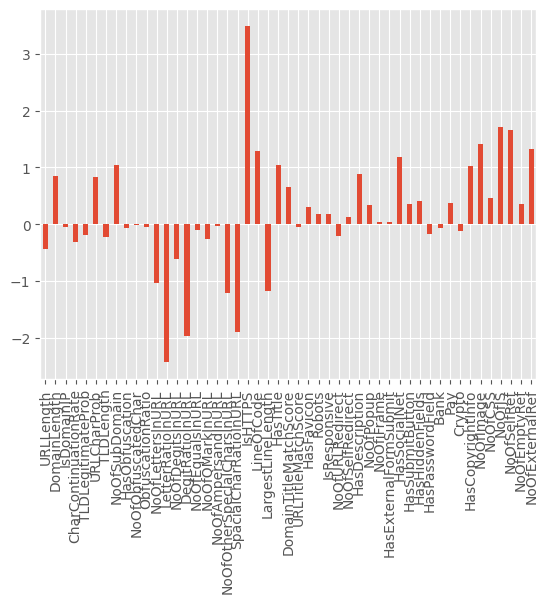

In [ ]:
# scale attributes by the training set
scl_obj = StandardScaler()
scl_obj.fit(X_train) # Finding the scale of X_train

X_train_scaled = scl_obj.transform(X_train) # apply to training
X_test_scaled = scl_obj.transform(X_test) # apply to test

# train the model 
lr_clf = LogisticRegression(C=0.05, solver='liblinear')
lr_clf.fit(X_train_scaled,y_train)  # train object with scaled data

y_hat = lr_clf.predict(X_test_scaled) # get predictions on scaled data

acc = mt.accuracy_score(y_test,y_hat)
conf = mt.confusion_matrix(y_test,y_hat)
print('accuracy:', acc )
print(conf )

# sorting attributes based on their weights
zip_vars = zip(lr_clf.coef_.T,df_dedup.columns) # combine attributes
zip_vars = sorted(zip_vars)
for coef, name in zip_vars:
    print(name, 'has weight of', coef[0]) # now print them out


# Plotting the weights
%matplotlib inline
plt.style.use('ggplot')

# Get column names excluding 'label'
feature_names = df_dedup.drop('label', axis=1).columns

weights = pd.Series(lr_clf.coef_[0], index=feature_names)
weights.plot(kind='bar')
plt.show()

SVM - Test/Train Split

In [ ]:
# Recreating the train/test and scaling for SVM
for train_indices, test_indices in cv_object.split(X,y): 
    X_train = X[train_indices]
    y_train = y[train_indices]
    
    X_test = X[test_indices]
    y_test = y[test_indices]
    
X_train_scaled = scl_obj.transform(X_train) # apply to training
X_test_scaled = scl_obj.transform(X_test) # apply to test

SVM - Fit Model

In [ ]:
# train the svm model similar to the logit model via object creating and training
svm_clf = SVC(C=0.5, kernel='linear', degree=3, gamma='auto') # get object
svm_clf.fit(X_train_scaled, y_train)  # train object with scaled data

y_hat = svm_clf.predict(X_test_scaled) # get predictions on scaled data

#Print accuracy and confusion matrix for SVM
acc = mt.accuracy_score(y_test,y_hat)
conf = mt.confusion_matrix(y_test,y_hat)
print('accuracy:', acc )
print(conf)

accuracy: 0.9995538938692272
[[19975    19]
 [    2 27078]]


SVM - Metric and Weights

(427, 49)
(427,)
[212 215]
[[-1.06234345e+00  1.95038545e+00  3.46944695e-18 -2.00156765e-01
  -6.12401443e-02  3.81170962e-01 -9.29511113e-02  3.21608381e-01
  -1.98357620e-02 -1.80163798e-03 -1.07874876e-02 -3.75816185e+00
  -1.47438558e+00 -1.62198077e+00 -1.21340822e+00 -1.11716192e-15
   2.35922393e-16 -1.20096620e-03 -1.12336552e+00 -8.08762719e-01
   2.87093831e+00  3.02181808e+00 -4.09602385e+00  5.09846597e-01
   6.61270614e-01 -4.73722854e-01  1.14232831e-01 -1.88617048e-02
   8.09665230e-02 -9.71183013e-02  1.71256299e-01  4.66251431e-01
   8.29777659e-01  1.45486058e-01 -7.97952344e-02  5.89513325e-01
   1.57753656e-01  1.70228907e-01 -1.09413531e-01 -5.68550739e-03
   1.82448680e-01 -3.64562769e-02  4.76848045e-01  3.13269194e+00
   1.48036985e+00  1.69031103e+00  3.44361282e+00  3.64669493e-01
   2.47104647e+00]]


<Axes: >

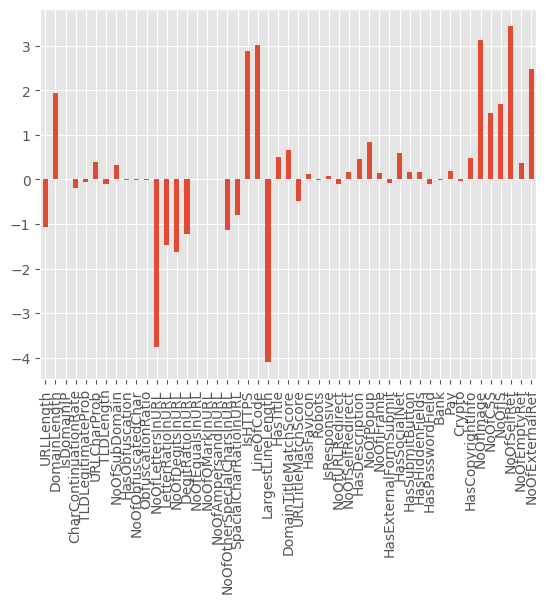

In [ ]:
# Print support vectors
print(svm_clf.support_vectors_.shape)
print(svm_clf.support_.shape)
print(svm_clf.n_support_ )

# Printing out coefficients for SVM
print(svm_clf.coef_)
weights = pd.Series(svm_clf.coef_[0],index=feature_names)
weights.plot(kind='bar')